데이터 로드 성공!
전체 데이터 행 수: 266


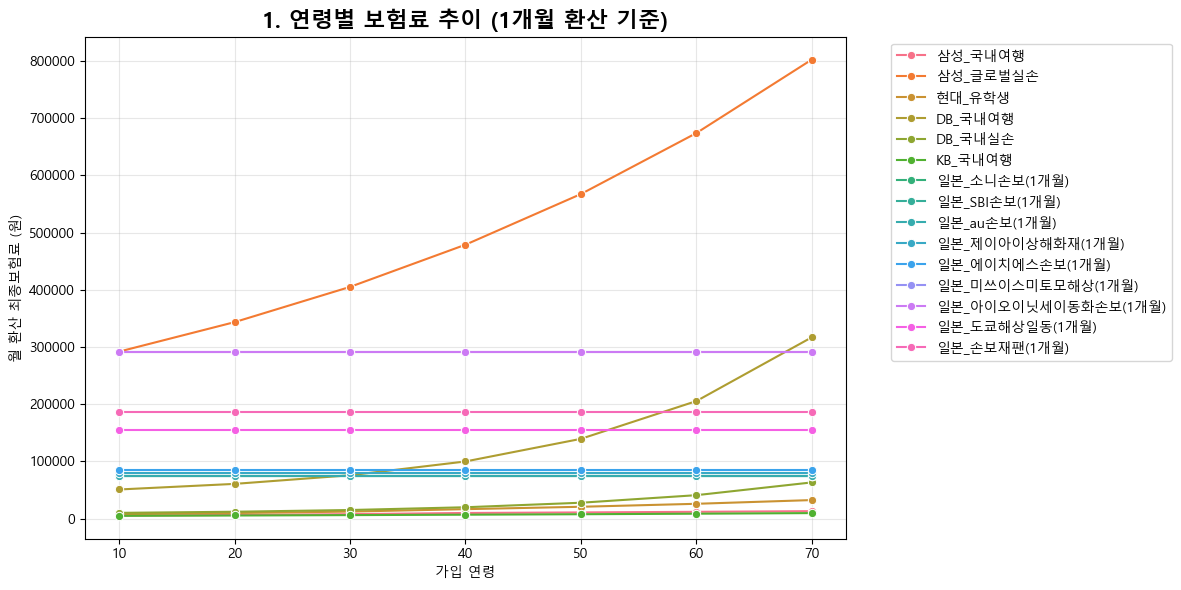

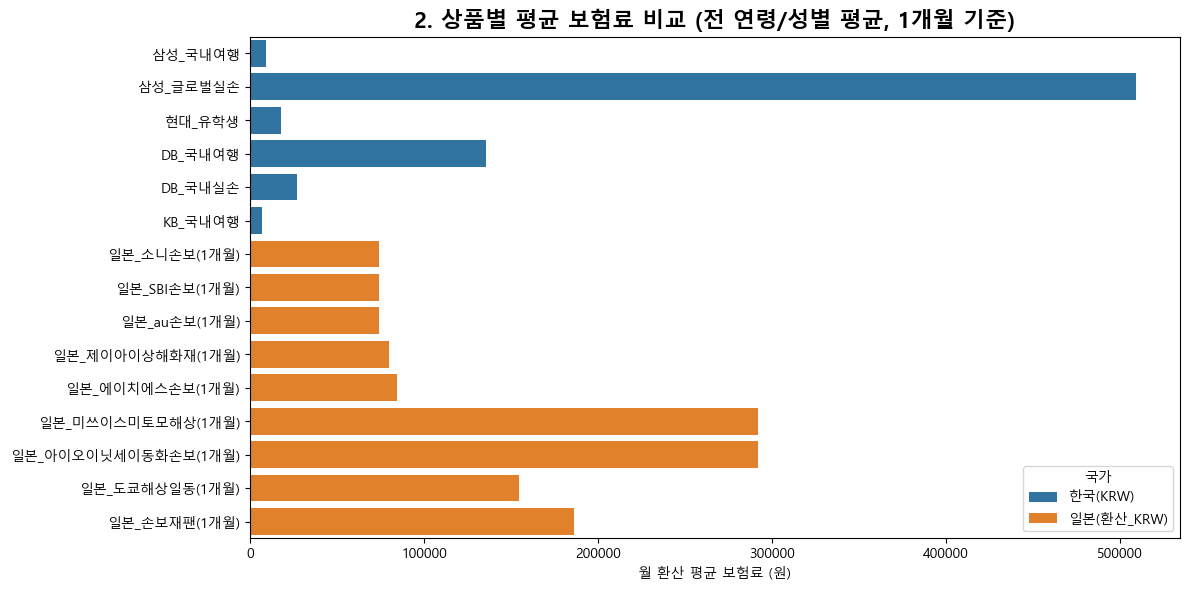

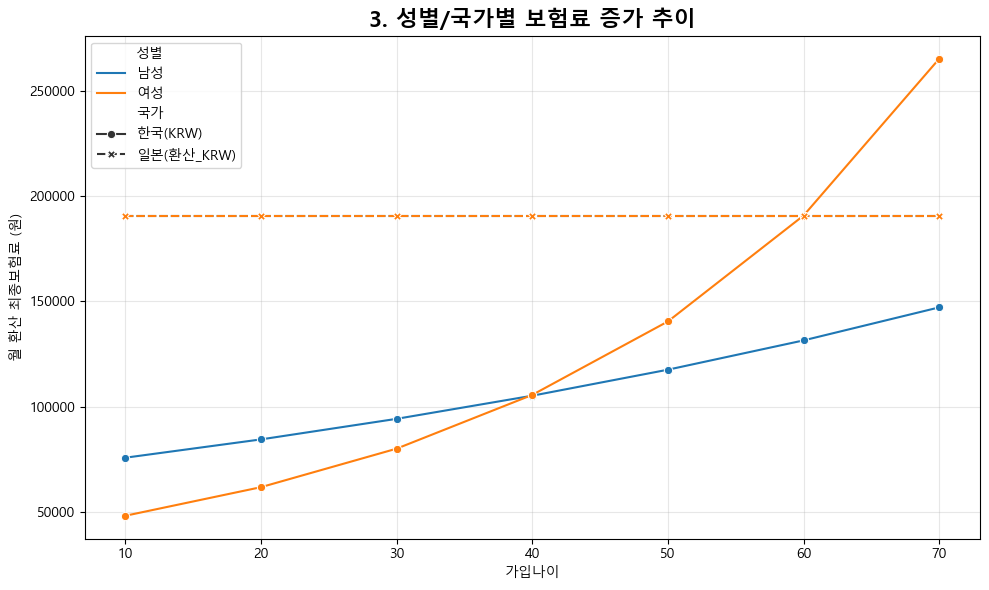

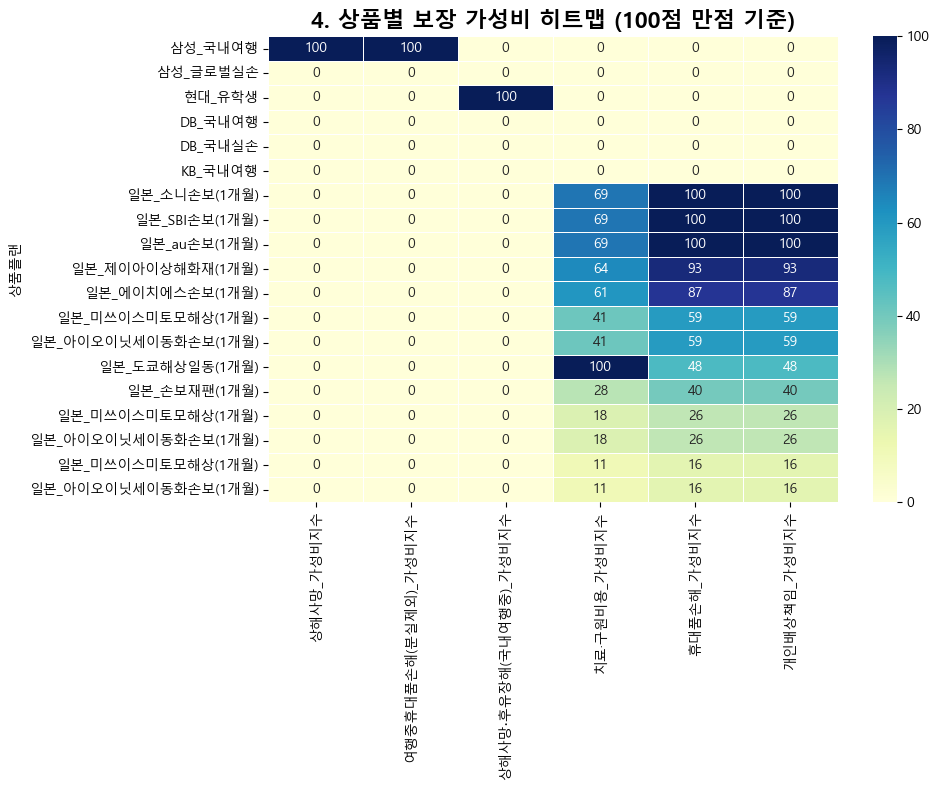

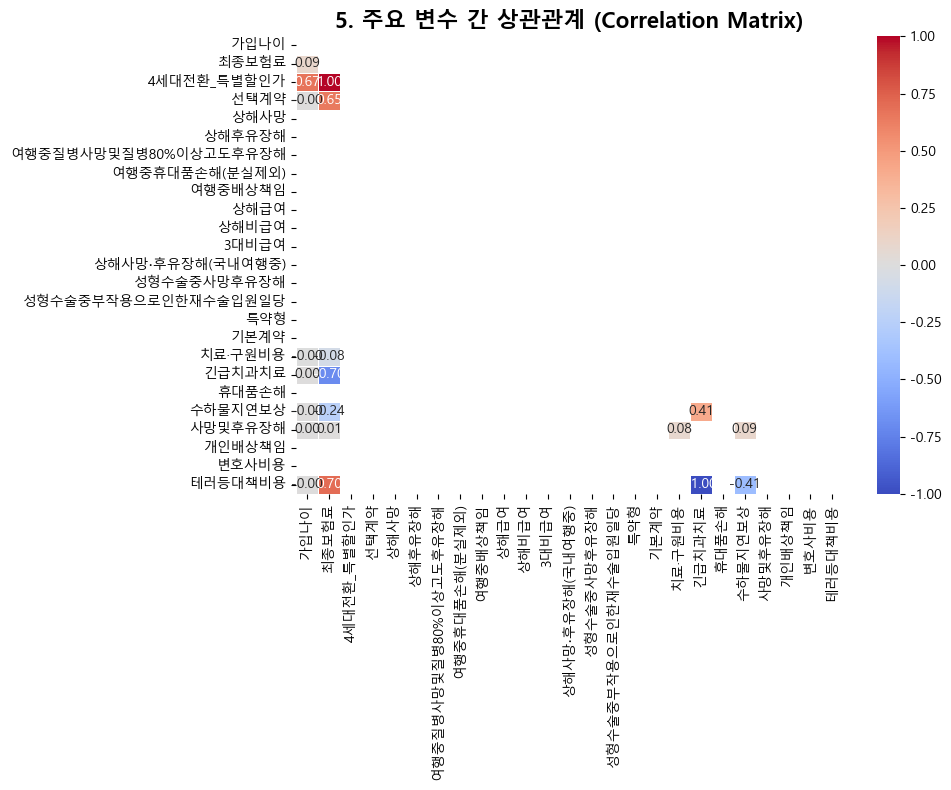

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import platform

# 1. 한글 폰트 및 마이너스 깨짐 방지 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 로드 (수민님 PC의 절대 경로 적용)
file_path = r"C:\Users\hahas\OneDrive\바탕 화면\문서\K-GMBA\module4\Machine Learing Business Applications\데이터수집(STEP2)\결과\통합_보험데이터_최종_디렉토리통일.csv"
df = pd.read_csv(file_path, encoding='utf-8-sig')

# 로드 확인
print("데이터 로드 성공!")
print(f"전체 데이터 행 수: {len(df)}")

# ---------------------------------------------------
# 분석 1. 연령별 보험료 추이 (국내 vs 해외 비교)
# ---------------------------------------------------
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='가입나이', y='최종보험료', hue='상품플랜', marker='o', errorbar=None)
plt.title("1. 연령별 보험료 추이 (1개월 환산 기준)", fontsize=16, fontweight='bold')
plt.ylabel("월 환산 최종보험료 (원)")
plt.xlabel("가입 연령")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("1_연령별_보험료추이.png")
plt.show()

# ---------------------------------------------------
# 분석 2. 회사별/국가별 평균 보험료 비교
# ---------------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='최종보험료', y='상품플랜', hue='국가', errorbar=None, dodge=False)
plt.title("2. 상품별 평균 보험료 비교 (전 연령/성별 평균, 1개월 기준)", fontsize=16, fontweight='bold')
plt.xlabel("월 환산 평균 보험료 (원)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("2_상품별_평균보험료.png")
plt.show()

# ---------------------------------------------------
# 분석 3. 성별 보험료 추이
# ---------------------------------------------------
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='가입나이', y='최종보험료', hue='성별', style='국가', markers=True, errorbar=None)
plt.title("3. 성별/국가별 보험료 증가 추이", fontsize=16, fontweight='bold')
plt.ylabel("월 환산 최종보험료 (원)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("3_성별_보험료추이.png")
plt.show()

# ---------------------------------------------------
# 분석 4. 보장별 가성비 히트맵
# ---------------------------------------------------
possible_covs = ['상해사망', '개인배상책임', '휴대품손해', '치료·구원비용']
found_covs = [col for col in df.columns if any(cov in col for cov in possible_covs)]

if found_covs:
    # 40세 남성 기준 가성비 (가입금액 / 보험료)
    df_efficiency = df[(df['가입나이'] == 40) & (df['성별'] == '남성')].copy()
    
    if not df_efficiency.empty:
        for cov in found_covs:
            df_efficiency[f'{cov}_가성비지수'] = df_efficiency[cov] / df_efficiency['최종보험료']
            
        eff_cols = [c for c in df_efficiency.columns if '가성비지수' in c]
        heatmap_data = df_efficiency.set_index('상품플랜')[eff_cols].fillna(0)
        
        # 정규화
        heatmap_data = heatmap_data.apply(lambda x: x / x.max() * 100 if x.max() > 0 else 0)

        plt.figure(figsize=(10, 8))
        sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
        plt.title("4. 상품별 보장 가성비 히트맵 (100점 만점 기준)", fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig("4_가성비_히트맵.png")
        plt.show()

# ---------------------------------------------------
# 분석 5. 변수 간 상관관계
# ---------------------------------------------------
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.loc[:, (numeric_df != 0).any(axis=0)]

if not numeric_df.empty:
    corr = numeric_df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, linewidths=.5)
    plt.title("5. 주요 변수 간 상관관계 (Correlation Matrix)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("5_상관관계.png")
    plt.show()